# 2 — What Brightway Can Do

This notebook is an **appetiser** — a complete worked example of a real-world LCA study. You do not need to understand every line of code yet. Run the cells, look at the outputs, and get a feel for where we are heading.

By the end of this class you will understand every piece of what happens here.

**What this notebook covers:**
- Installing a freely available background database (BAFU)
- Building a foreground inventory as a graph
- Running multi-method LCIA
- Visualising phase contributions

**What comes next:**
- Notebook 3 shows how to import this kind of data from an Excel spreadsheet
- Notebook 4 explains the matrices that make the calculation work

## Using LLMs in this notebook

Feel free to use Claude, ChatGPT, or Copilot if any cell is unclear. A good prompt: *"This uses bw2data and bw2calc. What does `lca.redo_lci()` do?"*

# Life Cycle Assessment: Swiss Residential Garden

## System Description

This notebook models the environmental impacts of **building and maintaining a 100 m² residential garden in Switzerland** over a **20-year lifespan**, including end-of-life waste treatment. It is a teaching exercise, and not intended to be used in real practice.

### Functional Unit

> **One 100 m² Swiss residential garden, fully constructed and maintained over 20 years**

### Garden Composition

| Zone | Area | Description |
|---|---|---|
| Lawn | 50 m² | Grass lawn, mown 20×/year |
| Planted beds | 20 m² | Shrubs, perennials, bark mulch |
| Hard surface | 20 m² | Natural stone path and patio |
| Trees & compost | 10 m² | 3 deciduous trees, compost corner |

### System Phases

1. **Construction** (one-time): site preparation, hard landscaping, lawn establishment, planting
2. **Annual maintenance** (×20 years): mowing, irrigation, fertilising, tool use, compost
3. **Green waste treatment** (×20 years): composting of grass clippings, anaerobic digestion of prunings
4. **End-of-life** (one-time): disposal of stone slabs and timber edging

Background data comes from **BAFU-2025-v2**, the Swiss Federal Office for the Environment LCI database, assessed with **Ecological Scarcity 2021**.

## System Diagram

```mermaid
flowchart TD
    FU(["<b>Functional Unit</b><br/>Swiss Residential Garden<br/>100 m² · 20 years"])

    subgraph FG ["Foreground System"]
        CON["Construction Phase<br/><i>×1</i>"]
        MAINT["Annual Maintenance<br/><i>×20 years</i>"]
        WASTE["Green Waste Treatment<br/><i>×20 years</i>"]
        EOL["End of Life<br/><i>×1</i>"]
    end

    subgraph BG ["Background — BAFU-2025-v2"]
        direction LR
        B1["Excavation · Transport<br/>Gravel · Stone · Timber<br/>Compost · Seedlings<br/>Wood chips · Grass seed"]
        B2["Mowing · Irrigation<br/>Tap water · Fertilisers N/P/K<br/>Electricity · Compost"]
        B3["Composting<br/>Anaerobic digestion<br/>Biowaste collection"]
        B4["Stone disposal<br/>Wood disposal<br/>Transport"]
    end

    FU --> CON
    FU --> MAINT
    FU --> WASTE
    FU --> EOL

    CON -->|"excavation 25 m³<br/>transport 270 t·km<br/>compost 1,100 kg<br/>gravel 3,200 kg<br/>stone 1,000 kg"| B1
    MAINT -->|"mowing 0.1 ha/yr<br/>irrigation 4 m³/yr<br/>tap water 4,000 kg/yr<br/>fertiliser N 0.75 kg/yr"| B2
    WASTE -->|"grass clippings 200 kg/yr<br/>prunings 100 kg/yr<br/>green waste 50 kg/yr"| B3
    EOL -->|"stone 20 m²<br/>wood 30 kg<br/>transport 5 t·km"| B4

    style FU fill:#2d6a4f,color:#fff,stroke:#1b4332
    style FG fill:#d8f3dc,stroke:#95d5b2
    style BG fill:#e9ecef,stroke:#adb5bd
```

## 1. Setup

In [1]:
import bw2data as bd
import bw2calc as bc
import bw2io as bi
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4g}'.format)

## 2. Install BAFU Background Database

Download and install the BAFU-2025-v2 project. This may take a minute on first run.

In [2]:
bi.remote.install_project("BAFU-2025-v2", overwrite_existing=True)

Restoring project backup archive - this could take a few minutes...


Restored project: BAFU 2025 v2


'BAFU 2025 v2'

## 3. Load Background Nodes

Set the active project and look up every background process we need by name and location.

In [3]:
bd.projects.set_current("BAFU 2025 v2")

bg = bd.Database("BAFU-2025-v2")
print(f"Background database: {len(bg)} activities")
print(f"LCIA methods: {len(list(bd.methods))}")

Background database: 11747 activities
LCIA methods: 21


In [4]:
# --- Construction ---
excavation      = bd.get_node(database="BAFU-2025-v2", name="Excavation, hydraulic digger, average", location="CH")
transport       = bd.get_node(database="BAFU-2025-v2", name="Transport, freight, lorry, diesel, 18t gross weight, 2010, EURO-V, urban delivery", location="CH")
compost         = bd.get_node(database="BAFU-2025-v2", name="xx Compost, at plant", location="CH")
gravel          = bd.get_node(database="BAFU-2025-v2", name="Gravel, round, market mix, at regional storage", location="CH")
stone_plate     = bd.get_node(database="BAFU-2025-v2", name="Natural stone plate, cut, market mix, at regional storage", location="CH")
sand_gravel     = bd.get_node(database="BAFU-2025-v2", name="Sand / concrete gravel, in sorting plant", location="CH")
timber          = bd.get_node(database="BAFU-2025-v2", name="Sawn timber, softwood, raw, air, kiln dried, u=6%, holzpur, at plant", location="CH")
tree_seedlings  = bd.get_node(database="BAFU-2025-v2", name="Tree seedling, from unheated greenhouse, 1000 units, at tree nursery", location="RER")
wood_chips      = bd.get_node(database="BAFU-2025-v2", name="Waste wood chips, mixed, from industry, u=40%, at plant", location="CH")
grass_seed      = bd.get_node(database="BAFU-2025-v2", name="Grass from natural meadow intensive IP, at field", location="CH")

# --- Maintenance ---
mowing          = bd.get_node(database="BAFU-2025-v2", name="Mowing, by rotary mower", location="CH")
irrigation      = bd.get_node(database="BAFU-2025-v2", name="Irrigation, sprinkler", location="CH")
tap_water       = bd.get_node(database="BAFU-2025-v2", name="Tap water, at user", location="CH")
fertilizer_n    = bd.get_node(database="BAFU-2025-v2", name="Average mineral fertiliser, as N, at regional storehouse", location="RER")
fertilizer_p    = bd.get_node(database="BAFU-2025-v2", name="Average mineral fertiliser, as P2O5, at regional storehouse", location="RER")
fertilizer_k    = bd.get_node(database="BAFU-2025-v2", name="Average mineral fertiliser, as K2O, at regional storehouse", location="RER")
electricity     = bd.get_node(database="BAFU-2025-v2", name="Electricity, low voltage, certified electricity, at grid", location="CH")

# --- Green waste ---
composting      = bd.get_node(database="BAFU-2025-v2", name="Composting organic waste", location="RER")
anaerobic_dig   = bd.get_node(database="BAFU-2025-v2", name="Disposal, biowaste, to anaerobic digestion", location="CH")
biowaste_coll   = bd.get_node(database="BAFU-2025-v2", name="Biowaste, at collection point", location="CH")

# --- End of life ---
stone_disposal  = bd.get_node(database="BAFU-2025-v2", name="Disposal, natural stone tiles, as building waste", location="CH")
wood_disposal   = bd.get_node(database="BAFU-2025-v2", name="Disposal, solid wood, as building waste", location="CH")

print("All background nodes found.")

All background nodes found.


## 4. Build the Foreground System

Each foreground process is paired with a product node. You saw this pattern in notebook 1.

In [5]:
# Create (or recreate) the foreground database.
FG_DB = "Swiss garden foreground"

if FG_DB in bd.databases:
    del bd.databases[FG_DB]

fg = bd.Database(FG_DB)
fg.register()
print(f"Created foreground database: '{FG_DB}'")

Created foreground database: 'Swiss garden foreground'


In [6]:
def new_fg_activity(process_code, product_code, process_name, product_name, unit="unit", location="CH"):
    """
    Create a foreground process + product node pair.

    The process node (type='process') represents the transformation.
    The product node (type='product') represents what is produced.
    A production exchange links process → product.

    Returns (process_node, product_node).
    """
    product = fg.new_node(
        code=product_code,
        name=product_name,
        unit=unit,
        location=location,
        type="product",
    )
    product.save()

    process = fg.new_node(
        code=process_code,
        name=process_name,
        unit=unit,
        location=location,
        type="process",
        **{"reference product": product_name},
    )
    process.save()

    # Production exchange: this process produces 1 unit of its product
    process.new_edge(input=product, amount=1.0, type="production").save()

    return process, product


garden_proc,  garden_prod  = new_fg_activity(
    "garden_system_proc",  "garden_system_prod",
    "Garden system",
    "Swiss residential garden, 100 m², 20 yr",
)
constr_proc,  constr_prod  = new_fg_activity(
    "construction_proc",   "construction_prod",
    "Garden construction",
    "Garden",
)
maint_proc,   maint_prod   = new_fg_activity(
    "annual_maintenance_proc", "annual_maintenance_prod",
    "Annual garden maintenance",
    "Garden maintenance",
)
waste_proc,   waste_prod   = new_fg_activity(
    "green_waste_proc",    "green_waste_prod",
    "Annual green waste treatment",
    "Treated green waste",
)
eol_proc,     eol_prod     = new_fg_activity(
    "end_of_life_proc",    "end_of_life_prod",
    "Garden end-of-life",
    "Garden disposal",
)

print("Foreground nodes created:")
for node in sorted(fg, key=lambda n: n["code"]):
    print(f"  [{node.get('type', 'process'):7s}]  {node['name']}  ({node['code']})")

Foreground nodes created:
  [process]  Annual garden maintenance  (annual_maintenance_proc)
  [product]  Garden maintenance  (annual_maintenance_prod)
  [process]  Garden construction  (construction_proc)
  [product]  Garden  (construction_prod)
  [process]  Garden end-of-life  (end_of_life_proc)
  [product]  Garden disposal  (end_of_life_prod)
  [process]  Garden system  (garden_system_proc)
  [product]  Swiss residential garden, 100 m², 20 yr  (garden_system_prod)
  [process]  Annual green waste treatment  (green_waste_proc)
  [product]  Treated green waste  (green_waste_prod)


In [7]:
def add_input(process_node, input_node, amount, comment=None):
    """Add a technosphere exchange: process_node consumes input_node."""
    exc = process_node.new_edge(input=input_node, amount=amount, type="technosphere")
    if comment:
        exc["comment"] = comment
    exc.save()

# ── garden_system consumes the *product* nodes of sub-processes ───────────────
add_input(garden_proc, constr_prod,  1,  "one-time construction")
add_input(garden_proc, maint_prod,  20,  "20 years of maintenance")
add_input(garden_proc, waste_prod,  20,  "20 years of waste treatment")
add_input(garden_proc, eol_prod,     1,  "end-of-life disposal")

# ── construction → BAFU background activities ─────────────────────────────────
add_input(constr_proc, excavation,      25,    "25 m³ topsoil removal")
add_input(constr_proc, transport,      270,    "270 t·km: soil out + materials in")
add_input(constr_proc, compost,       1100,    "compost for beds and lawn (kg)")
add_input(constr_proc, gravel,        3200,    "gravel sub-base under hard surface (kg)")
add_input(constr_proc, stone_plate,   1000,    "natural stone slabs, 20 m² × 50 kg/m² (kg)")
add_input(constr_proc, sand_gravel,    800,    "bedding sand under stone (kg)")
add_input(constr_proc, timber,         0.06,   "timber edging, 20 lin. m (m³)")
add_input(constr_proc, tree_seedlings, 0.003,  "3 trees (process unit = 1000 seedlings)")
add_input(constr_proc, wood_chips,     0.6,    "bark mulch for beds, ~300 kg ≈ 0.6 m³")
add_input(constr_proc, grass_seed,     5,      "grass seed for 50 m² lawn (kg)")

# ── annual_maintenance → BAFU ─────────────────────────────────────────────────
add_input(maint_proc, mowing,          0.10,   "50 m² × 20 cuts = 0.10 ha")
add_input(maint_proc, irrigation,      4,      "summer irrigation, 4 m³/yr")
add_input(maint_proc, tap_water,    4000,      "tap water for irrigation (kg)")
add_input(maint_proc, fertilizer_n,    0.75,   "N fertiliser for 50 m² lawn (kg N)")
add_input(maint_proc, fertilizer_p,    0.15,   "P₂O₅ fertiliser (kg)")
add_input(maint_proc, fertilizer_k,    0.25,   "K₂O fertiliser (kg)")
add_input(maint_proc, electricity,     10,     "electric garden tools (kWh)")
add_input(maint_proc, compost,        100,     "compost top-dressing for beds (kg)")

# ── green_waste_treatment → BAFU ─────────────────────────────────────────────
add_input(waste_proc, composting,     200,     "grass clippings composted (kg)")
add_input(waste_proc, anaerobic_dig,  100,     "prunings to anaerobic digestion (kg)")
add_input(waste_proc, biowaste_coll,   50,     "residual green waste to collection (kg)")

# ── end_of_life → BAFU ───────────────────────────────────────────────────────
add_input(eol_proc, stone_disposal,    20,     "stone slab disposal, 20 m²")
add_input(eol_proc, wood_disposal,     30,     "weathered timber edging disposal (kg)")
add_input(eol_proc, transport,          5,     "waste transport to disposal, 5 t·km")

print("All edges created.")

All edges created.


### Exercise 1: Inspect the foreground

How many nodes are in the foreground database? How many edges? Write a one-liner for each.

In [8]:
# Your code here

## 5. LCA Calculations

We use **Ecological Scarcity 2021** across four impact categories.

| Category | Unit |
|---|---|
| Global warming | UBP (eco-points) |
| Main air pollutants and PM | UBP |
| Water pollutants | UBP |
| Land use | UBP |

In [9]:
METHODS = [
    ("Ecological Scarcity 2021", "Global warming"),
    ("Ecological Scarcity 2021", "Main air pollutants and PM"),
    ("Ecological Scarcity 2021", "Water pollutants"),
    ("Ecological Scarcity 2021", "Land use"),
]

# Demand is placed on the *product* node — 1 unit of the complete garden.
fu = {garden_prod: 1}

lca = bc.LCA(fu, method=METHODS[0])
lca.lci()
lca.lcia()

print(f"Method: {METHODS[0]}")
print(f"Total score: {lca.score:,.0f} UBP")

Method: ('Ecological Scarcity 2021', 'Global warming')
Total score: 377,568 UBP


/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.56e+12)
  warnings.warn(msg, UmfpackWarning)


### Exercise 2: Different method

The code above calculates the Global Warming score. Change the method to "Main air pollutants and PM" and recalculate. What is the score?

In [10]:
lca.switch_method(METHODS[1])
lca.redo_lcia()
# What is the score?

### 5.1 Multi-Method Phase Comparison

Re-run the LCA for each phase separately across all four methods to see which life-cycle stage drives which impact.

In [11]:
# Phase demands are placed on product nodes (redo_lci uses integer ids).
phase_nodes = {
    "Construction":          {constr_prod.id: 1},
    "Maintenance (×20)":   {maint_prod.id:  20},
    "Waste treatment (×20)": {waste_prod.id:  20},
    "End of life":           {eol_prod.id:    1},
}

results = {}  # {method_label: {phase: score}}

for method in METHODS:
    label = method[1]
    results[label] = {}
    lca.switch_method(method)
    for phase, fu_phase in phase_nodes.items():
        lca.redo_lci(fu_phase)
        lca.redo_lcia()
        results[label][phase] = lca.score

results_df = pd.DataFrame(results)
print("Phase scores by impact category (UBP):")
results_df

Phase scores by impact category (UBP):


,Global warming,Main air pollutants and PM,Water pollutants,Land use
Construction,3.146e+05,5.88e+04,5791,5732
Maintenance (×20),4.695e+04,6024,1559,1075
Waste treatment (×20),5812,678.7,147.4,45.6
End of life,1.023e+04,1481,126.7,198.5


### 5.2 Visualise: Phase Contributions Across Impact Categories

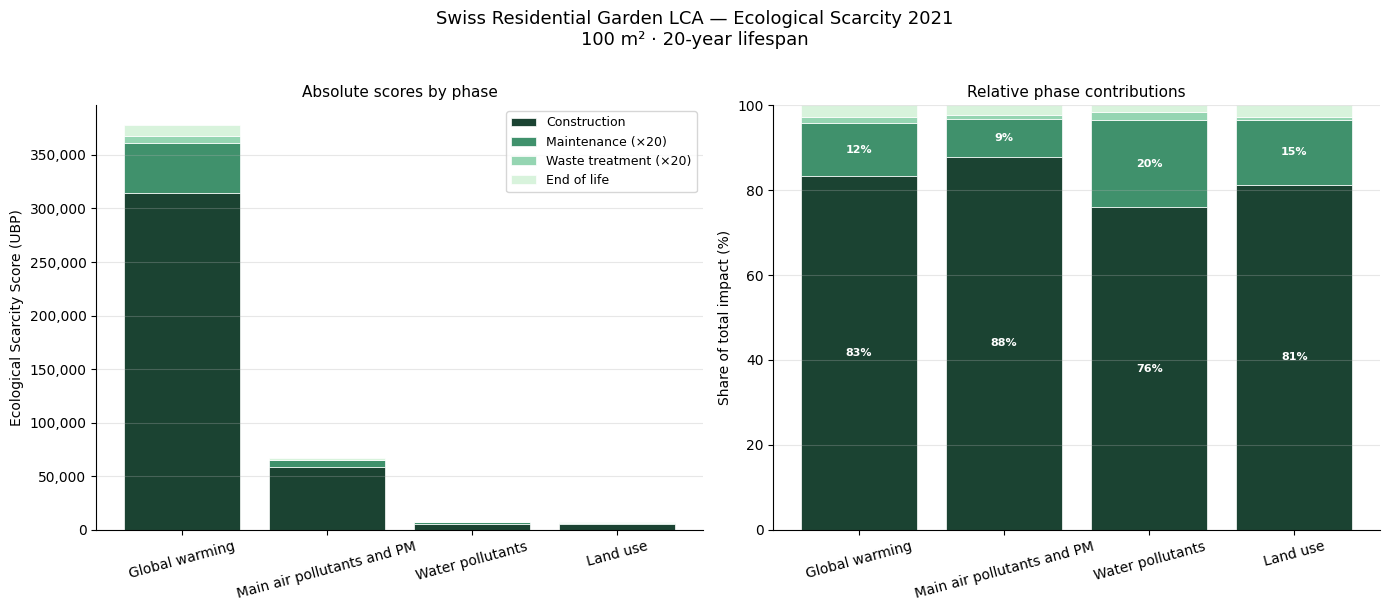

In [12]:
# Normalise each method to 100% for easier visual comparison
results_pct = results_df.div(results_df.sum(axis=0), axis=1) * 100

phases = results_pct.index.tolist()
method_labels = results_pct.columns.tolist()

phase_colors = {
    "Construction":           "#1b4332",
    "Maintenance (×20)":     "#40916c",
    "Waste treatment (×20)": "#95d5b2",
    "End of life":            "#d8f3dc",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: absolute scores ──────────────────────────────────────────────────────
ax = axes[0]
bottom = np.zeros(len(method_labels))
for phase in phases:
    vals = results_df.loc[phase].values
    ax.bar(method_labels, vals, bottom=bottom, label=phase,
           color=phase_colors[phase], edgecolor="white", linewidth=0.5)
    bottom += vals

ax.set_ylabel("Ecological Scarcity Score (UBP)", fontsize=10)
ax.set_title("Absolute scores by phase", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", labelrotation=15)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right", framealpha=0.8, fontsize=9)

# ── Right: normalised (%) ──────────────────────────────────────────────────────
ax = axes[1]
bottom = np.zeros(len(method_labels))
for phase in phases:
    vals = results_pct.loc[phase].values
    ax.bar(method_labels, vals, bottom=bottom, label=phase,
           color=phase_colors[phase], edgecolor="white", linewidth=0.5)
    # Label segments > 8%
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax.text(i, b + v / 2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals

ax.set_ylabel("Share of total impact (%)", fontsize=10)
ax.set_title("Relative phase contributions", fontsize=11)
ax.set_ylim(0, 100)
ax.tick_params(axis="x", labelrotation=15)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Swiss Residential Garden LCA — Ecological Scarcity 2021\n"
             "100 m² · 20-year lifespan", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Exercise 3: Dominant phase

Looking at the chart: which life-cycle phase dominates for Land Use? Does this surprise you? Discuss briefly with your neighbour or ask an LLM to explain why land use impacts might be concentrated in a particular phase.

In [13]:
# Your code here (or just think about it)

## What just happened?

In about 50 lines of code, you:
1. Installed a national LCI database (BAFU, Switzerland)
2. Built a foreground system as a graph of processes and products
3. Calculated environmental impacts across four categories
4. Visualised which life-cycle phase matters most

**In the next notebooks:**
- **Notebook 3** shows how this data could come from an Excel spreadsheet, and the work needed to link it to a background database
- **Notebook 4** reveals the matrices hidden inside `lca.lci()` and `lca.lcia()`
- **Notebook 5** shows how to make edges in the graph dynamic — scenarios, time variation, provider mixes